- conditional edge를 활용
- 생성한 답변이 좋으면 generate로, 나쁘면 사용자의 질문을 rewrite로 수정한 다음, 문서를 다시 가져오는 절차
- [검증] 노드가 추가됨

In [1]:
# 필요한 노드

# 1. retrieve
# 2. generate
# 3. rewrite (conditional edge에서 활용)
# 4. 문서 검증

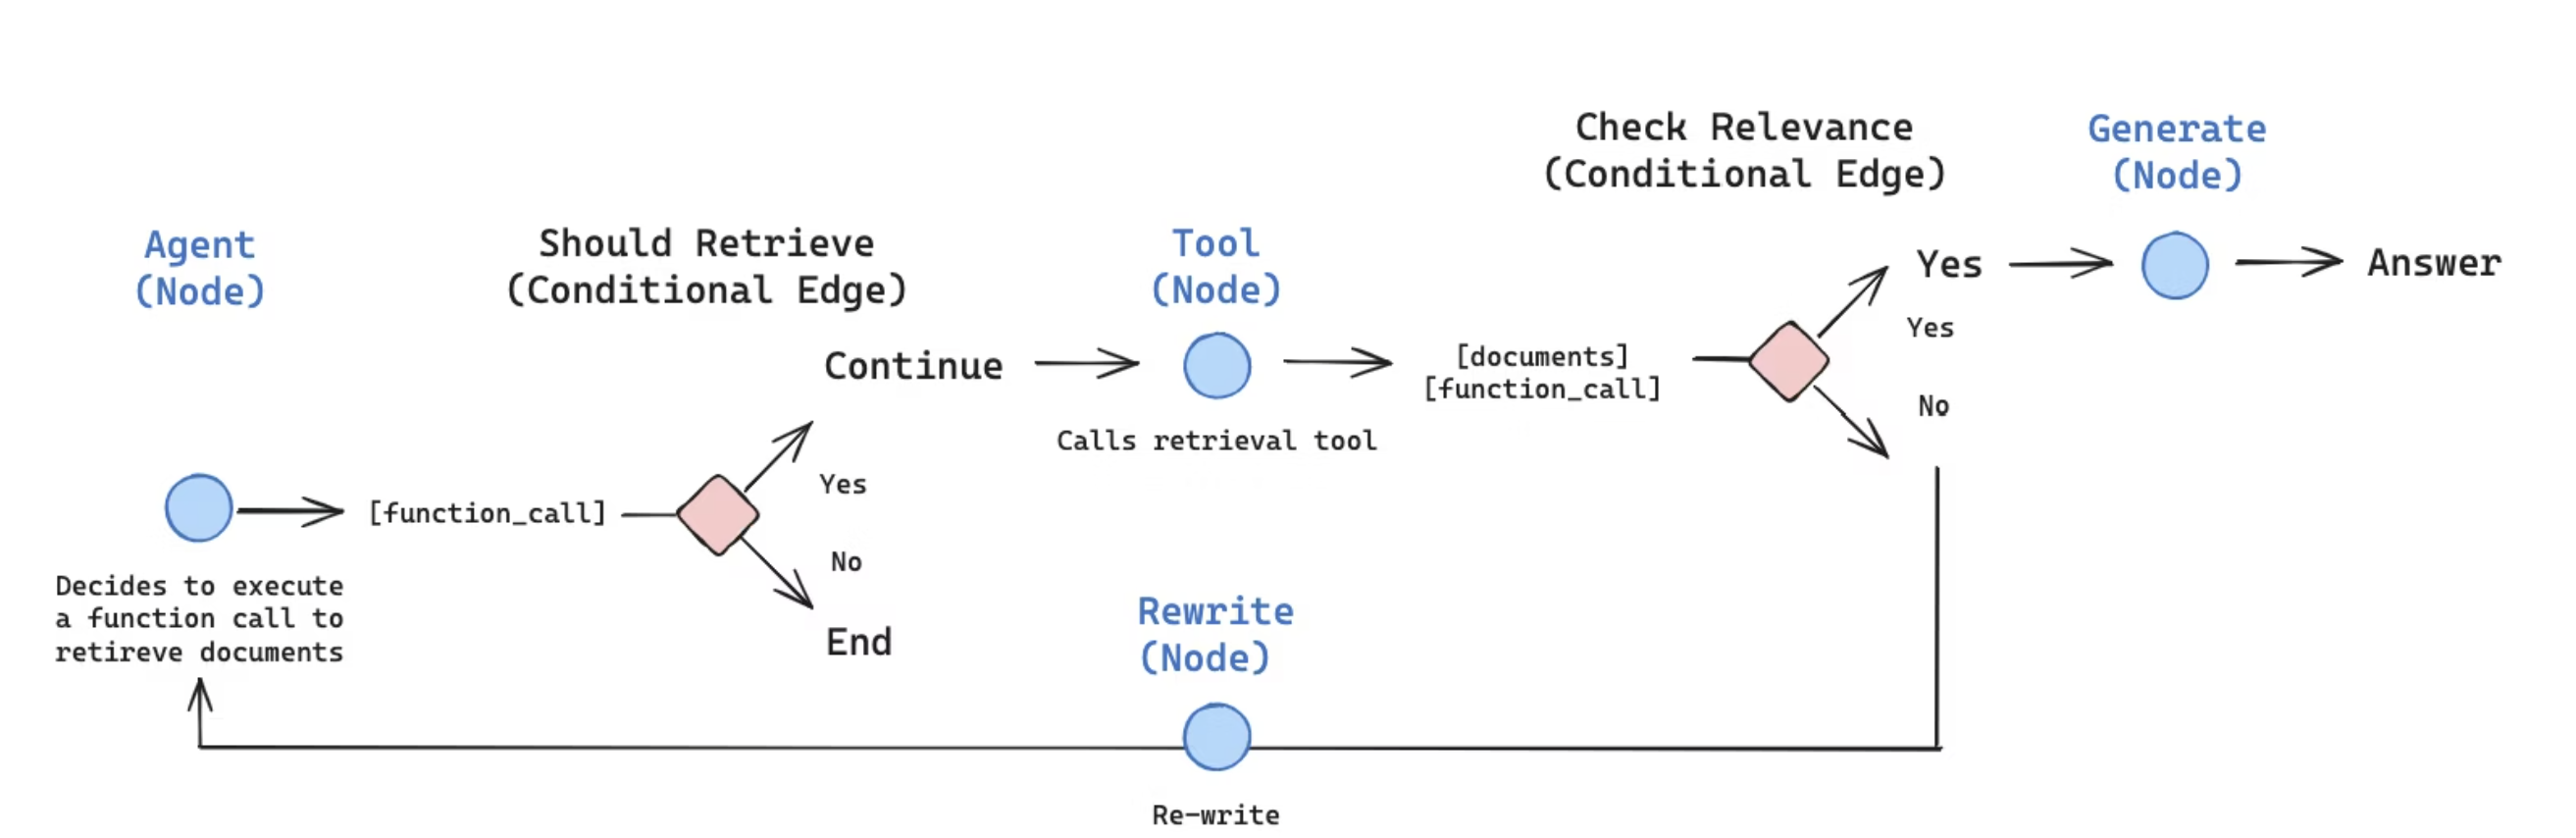

- 공식문서 상, retrieve 로 가져온 문서가 [Check Relevance] No의 흐름을 타게 되면, End 되어버리는 경우가 많다
- [Should Retrieve] 를 없애고, 사용자의 질문을 바로 retrieve 하는 구조로 변경해서 진행
    - rewrite 해서 바로 retrieve

In [2]:
# 생성된 벡터스토어에 접근 -> 클래스만 바로 써야 함
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='income_tax_collection',
    persist_directory='./income_tax_collection'  # 로컬에 남아있음
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})  # 검색할 때, 가장 유사한 3개의 문서를 가져오도록 설정

In [3]:
# state 생성

from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str   # 사용자의 질문
    context:List[Document]  # 답변을 만들때 참고할 문서들 - langchain의 다큐먼트들을 리스트 형태로 반환 
    answer: str


graph_builder = StateGraph(AgentState)  # 빌더 생성

In [4]:
# 노드 생성

# retrieve
def retrieve(state:AgentState):
    query = state['query']  # 사용자의 질문을 꺼내온다
    docs = retriever.invoke(query)  # 사용자의 질문을 기반으로 문서 검색
    return {'context' : docs}    # 검색된 결과를  state의 context에 넣어서 반환


- 이번에는 generate용 프롬프트, rewrite용 프롬프트, 문서 관련성 측정용 프롬프트가 각각 있어야 함

In [5]:
# llm과 prompt 분리 
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model='gpt-4o')  # 가격을 위해서 mini로 대체

In [ ]:
from langchain_classic import hub

generate_prompt = hub.pull("rlm/rag-prompt")


# generate
def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context':context})
    return {'answer' : response}

In [7]:
from langchain_classic import hub
from typing import Literal
doc_relevance_prompt = hub.pull("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['relevant', 'irrelevant']: 
    context = state['context']
    query = state['query']
    print(f'context == {context}') 
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents':context}) 
    print(f'doc relevance response == {response}') 
    if response['Score'] == 1:
        return 'generate'
    
    return 'rewrite'

In [8]:
# 검색이 왜 안되었는가? 를 봐야한다
# 원본 문서 상 "거주자의 종합소득, 퇴직소득~" 이렇게 되어있고, 사용자의 질문은 "직장인의 소득세~"이렇게 되어있음
# 그래서 검색이 안됨

# "직장인", "내가 연봉~" -> 이런 표현들을 "거주자" 로 바꿔줘야 한다

In [9]:
# prompt = ChatPromptTemplate.from_template(f"""
#     사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.
#     만약 변경할 필요가 없다고 판단된다면, 사용자의 질문을 변경하지 않아도 됩니다.
#     그런 경우에는 질문만 리턴해주세요
#     사전 : {dictionary}
#     사용자의 질문 : {{question}}
                                          
# """)

# langchain의 프롬프트와 비교 ***
# 위 프롬프트는 사용자가 어떤 질문을 하는가에 상관없이, 검증하지 않고 바로 체인을 돌렸기 때문.
# 이번에는 관련성을 검증한 다음에 -> rewrite를 돌리는 것이기 때문에, 아래 프롬프트 처럼 중간 내용이 빠지게 된다

In [10]:
# 위 문제를 해결하기 위한 템플릿 직접 작성

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


# dictionary 추가 : LLM invoke 시, 답변 생성이 제대로 안나옴
dictionary = ['사람과 관련된 표현 -> 거주자', '연봉과 관련된 표현 -> 종합소득', '퇴직금과 관련된 표현 -> 퇴직소득']  # 예시 사전
              
rewrite_template = PromptTemplate.from_template(f"""
    사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요
    사전 : {dictionary}
    질문 : {{query}}
    """
)

def rewrite(state: AgentState):
    query = state['query']

    # response (output)을 string만 나오게끔 변경 (state의 query 타입이 str이므로, str을 받을 수 있게 타입을 변경해주자)
    rewrite_chain = rewrite_template | llm | StrOutputParser()  # output이 string이 되도록 체인에 파서 연결
    response = rewrite_chain.invoke({'query': query})  # [response] : 원래 AIMessage타입이었는데, StrOutputParser() 때문에 string 타입으로 바뀜
    
    return {'query': response}

In [11]:
graph_builder.add_node('retrieve', retrieve)

# check_doc_relevance는 conditional edge에서 활용하기 위해서, graph_builder.add_node로 등록하지 않음
# graph_builder.add_node('check_doc_relevance', check_doc_relevance)

graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

# 노드 등록

In [12]:
# 플로우 구축

from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')

# conditional edge 를 generate, rewrite가 아니라 check_doc_relevance 에 넣어준다. [플로우를 생각] - langgraph의 문법
# graph_builder.add_conditional_edges('retrieve', generate)
# graph_builder.add_conditional_edges('retrieve', rewrite)
graph_builder.add_conditional_edges('retrieve', check_doc_relevance)


graph_builder.add_edge('rewrite', 'retrieve')  # rewrite가 끝나면 다시 retrieve로 돌아가도록 연결
graph_builder.add_edge('generate', END)

In [13]:
graph = graph_builder.compile()

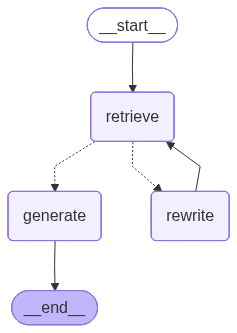

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))  

#### initial state 설정

In [15]:
initial_state = {'query': '연봉 5천만원 세금'}  # 초기 상태 정의
graph.invoke(initial_state)

context == [Document(id='ae5669ef-f49c-4f5c-91b9-bc280eb0f852', metadata={'source': './docs/income_tax.txt'}, page_content='만일 이하의 자기 주택임대소득(2018년 12월 31일 이전에 말하는 과세기간까지 발생하는 소득으로 한정한다.\n다. 대통령령으로 정하는 정년보장제도에 발생하는 소득\n라. 대통령령으로 정하는 전적소득 제도에 발생하는 소득\n마. 조기퇴직 그 내 이상의 임징(任職)에서 원익 또는 양으로 발생하는 소득으로 연 600만원 이하의 금액에, 의 경우 조기퇴직 인 원의 필요와 사유로 발생하는 소득으로 정한다.\n바. 대통령령으로 정하는 작업재배형에서 발생하는 소득\n사. 대통령령으로 정하는 매도나 양식업에서 발생하는 소득'), Document(id='7d1fe2bc-d57d-4067-a42d-065188965264', metadata={'source': './docs/income_tax.txt'}, page_content='나. 단위표로액 합계액이 단위투표금의 100만원 이하이면서 적종한 개별투표 경우\n다. 제21조제3항제1호에 따른 복권 당첨금(복권당첨금을 복권 및 복권 기법법에 따라 분할하여 지급받는 경우에는 본항에 지급받는 금액의 합계액을 말한다) 또는 제21조제1항제14호에 따른 당첨금총액의 건별로 200만원 이하인 경우 \n라. 그 밖의 기타소득엑(제21조제1항제21호의 기타소득금액은 제외한다)이 건별로 5만원 이하인 경우 [전문개정 2009. 12. 31.]\n제2항 세액의 정수와 합산\n<개정 2009. 12. 31.>\n제86조(장수와 합금)\n남세지 관할 세무서장은 거주자 그 다음 각 호의 어느 하나에 해당하면 그 미달된 부분의 소득세를 "국세청장이"법에 따라 장수한다. <개정 2013. 1. 1.>'), Document(id='9687cef7-b202-4f20-a7c9-e0686d20eddf', metadata={'source': 

{'query': '연봉 5천만원 세금',
 'context': [Document(id='ae5669ef-f49c-4f5c-91b9-bc280eb0f852', metadata={'source': './docs/income_tax.txt'}, page_content='만일 이하의 자기 주택임대소득(2018년 12월 31일 이전에 말하는 과세기간까지 발생하는 소득으로 한정한다.\n다. 대통령령으로 정하는 정년보장제도에 발생하는 소득\n라. 대통령령으로 정하는 전적소득 제도에 발생하는 소득\n마. 조기퇴직 그 내 이상의 임징(任職)에서 원익 또는 양으로 발생하는 소득으로 연 600만원 이하의 금액에, 의 경우 조기퇴직 인 원의 필요와 사유로 발생하는 소득으로 정한다.\n바. 대통령령으로 정하는 작업재배형에서 발생하는 소득\n사. 대통령령으로 정하는 매도나 양식업에서 발생하는 소득'),
  Document(id='7d1fe2bc-d57d-4067-a42d-065188965264', metadata={'source': './docs/income_tax.txt'}, page_content='나. 단위표로액 합계액이 단위투표금의 100만원 이하이면서 적종한 개별투표 경우\n다. 제21조제3항제1호에 따른 복권 당첨금(복권당첨금을 복권 및 복권 기법법에 따라 분할하여 지급받는 경우에는 본항에 지급받는 금액의 합계액을 말한다) 또는 제21조제1항제14호에 따른 당첨금총액의 건별로 200만원 이하인 경우 \n라. 그 밖의 기타소득엑(제21조제1항제21호의 기타소득금액은 제외한다)이 건별로 5만원 이하인 경우 [전문개정 2009. 12. 31.]\n제2항 세액의 정수와 합산\n<개정 2009. 12. 31.>\n제86조(장수와 합금)\n남세지 관할 세무서장은 거주자 그 다음 각 호의 어느 하나에 해당하면 그 미달된 부분의 소득세를 "국세청장이"법에 따라 장수한다. <개정 2013. 1. 1.>'),
  Document(id='9687cef7-b202-4f20-a7c9-e0686d

- 아래 이미지를 참고하면, 
---
1. 처음 가져온 문서는 not relevant
2. 질문을 바꿔서 답변 생성
2-1. "연봉 5천만원 세금" --> "거주자의 연봉 5천만원에 대한 세금은 어떻게 되나요?" 로 바꾸고, 이로 인해 문서를 제대로 가지고 오는 것을 확인할 수 있다
2-2. 올바른 답변이 생성되는가 --> 애매함
    - 전처리된 문서를 다시 확인해볼 것 -> 오타, 표 인식 오류 etc
    - Q. 사용자가 질문할때는 정확한 단어를 입력할 확률이 적을것으로 생각되서 이 경우 쿼리에 대해 llm 이나 다른 방법을 통해 알아서 잘(?) 질문에 대해서 llm이 해석 할 수 있도록 해줄 필요가 있을 것 같다고 생각이 듦
        - 우리의 문서에 있는 단어와 사용자들이 자주 쓰는 단어가 다르다면, 사전을 만들어서 해당 단어를 치환해 주는 방식이 가장 편리할수도 있다. 
        - 직장인 -> 거주자, 사람 -> 거주자, 누군가 -> 거주자 이런 식으로 치환을 해도 되고 (LLM을 호출하지 않고 regex기반으로 처리한다면 토큰비용이 저감되고 속도가 훨씬 빠르겠죠)
        - 아니면 node를 하나 추가해서, "사람을 뜻하는 단어를 모두 거주자로 바꿔달라"라는 작업을 해도 된다. 이것 역시 간단한 작업이라고 판단되면 작은 모델을 사용해서 저렴한 비용과 빠른 연산으로 해당 작업을 처리할 수도 있다. 

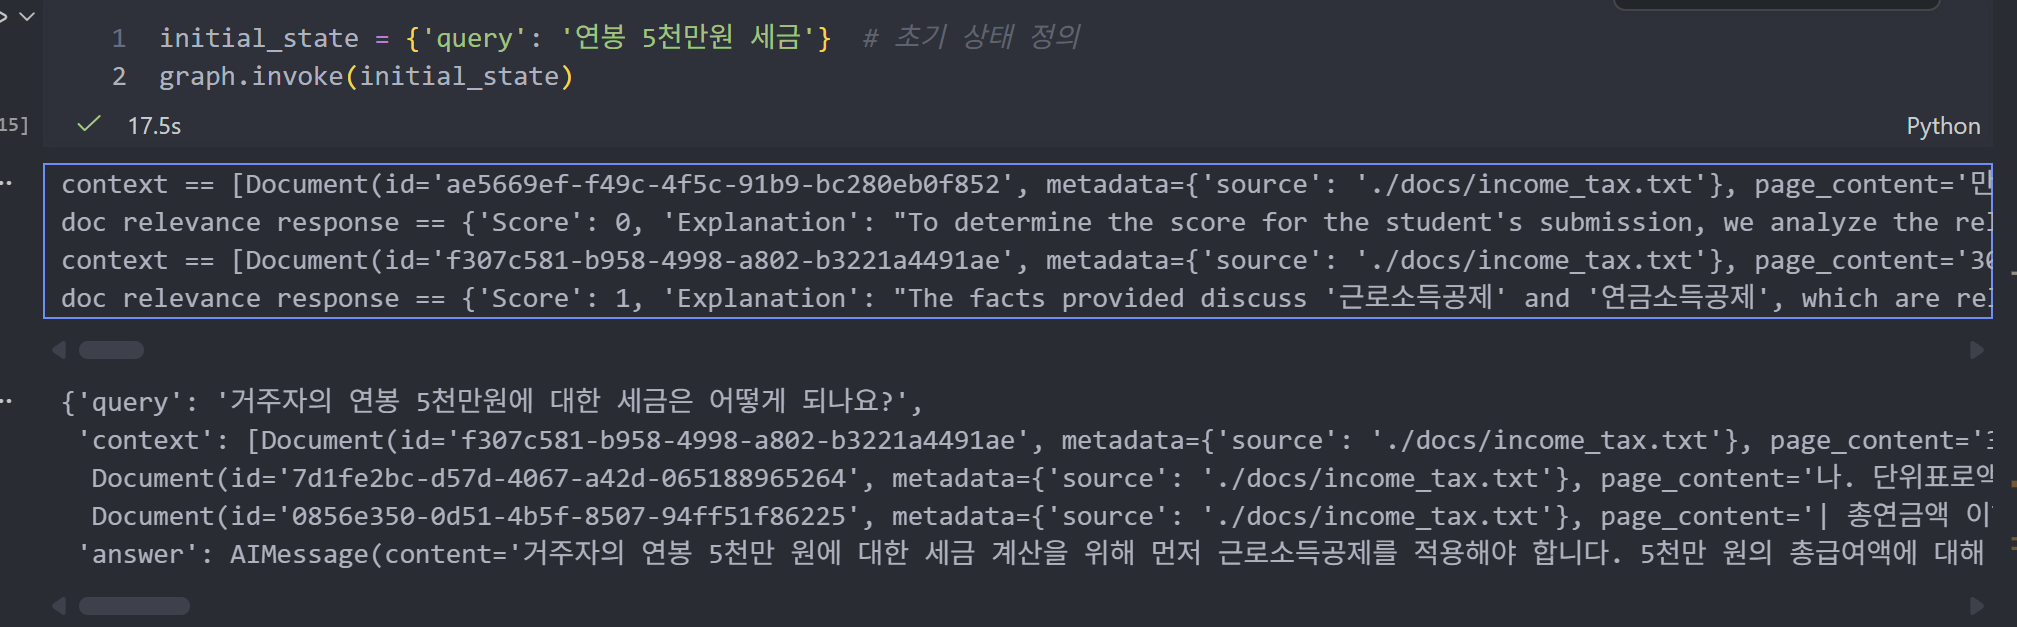

> 'answer': AIMessage(content='연봉 5천만 원에 대한 세율은 34%입니다. 이는 5,000만 원 초과 구간의 세율로, 해당 금액을 초과하는 부분에 대해 세율이 적용됩니다. 더 구체적인 세액 계산을 위해서는 개인 공제 및 기타 조건을 고려해야 합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 1307, 'total_tokens': 1377, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_041f18373b', 'id': 'chatcmpl-DK3mjYJOeCE4VxN97joPTfLfhWDU8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf72d-8645-7792-9d82-82903c9b78e0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1307, 'output_tokens': 70, 'total_tokens': 1377, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}